# Project Hail Query


## Table of Contents


* Load Datasets
* General EDA
* Normalize Column Names
* Project Feasibility EDA
* Preprocessing
     * Data Cleaning
        * Amazon Ratings Dataset (ARD)
        * **Prepare ARD for Collaborative Filtering (potentially on MySQL)**
        * Second Dataset (7k Books)

* **Join Datasets (potentially on MySQL)**
* **Create Colaborative Filtering Matrix (potentially on MySQL)**





Disclaimer: I still came to the same conclusion even after revising the logic, code and fixing errors the isbn10 overlap is between amazon_data_ratings and books_7k is still too low for a join. This is a shortened clean version. The normalization I did step by step to avoid errors but could probably be simplifed with one code block.

# Load Datasets

In [1]:
# Load Libraries
import os
import pandas as pd
import numpy as np
import textwrap
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path
import seaborn as sns




In [2]:
# define directory
BASE_DIR = Path("../data")
print("BASE_DIR:", BASE_DIR)
print("type:", type(BASE_DIR))
print("exists:", BASE_DIR.exists())
print(os.listdir(BASE_DIR))

BASE_DIR: ../data
type: <class 'pathlib.PosixPath'>
exists: True
['amazon_books_reviews', '.gitkeep', 'clean', 'bookcrossing', '7k_books']


In [3]:
# overview datasets
for dataset in sorted(BASE_DIR.iterdir()):
    if dataset.is_dir():
        print(f"\n📁 {dataset.name}")
        for root, dirs, files in os.walk(dataset):
            rel_root = os.path.relpath(root, dataset)
            if files:
                print("  /" if rel_root == "." else f"  /{rel_root}")
                for file in sorted(files):
                    print(f"    - {file}")


📁 7k_books
  /
    - books.csv

📁 amazon_books_reviews
  /
    - Books_rating.csv
    - books_data.csv

📁 bookcrossing
  /Books Data with Category Language and Summary
    - Preprocessed_data.csv
  /Book reviews
    - BX-Book-Ratings.csv
    - BX-Users.csv
    - BX_Books.csv

📁 clean
  /
    - amazon_books_ratings_clean.csv


In [4]:
# load all datasets
books_7k = pd.read_csv(f"{BASE_DIR}/7k_books/books.csv")

amazon_books_data = pd.read_csv(f"{BASE_DIR}/amazon_books_reviews/books_data.csv")
amazon_books_ratings = pd.read_csv(f"{BASE_DIR}/amazon_books_reviews/Books_rating.csv")

bx_users = pd.read_csv(f"{BASE_DIR}/bookcrossing/Book reviews/BX-Users.csv", sep=';', encoding='latin-1')
bx_books = pd.read_csv(f"{BASE_DIR}/bookcrossing/Book reviews/BX_Books.csv", sep=';', encoding='latin-1')
bx_ratings = pd.read_csv(f"{BASE_DIR}/bookcrossing/Book reviews/BX-Book-Ratings.csv", sep=';', encoding='latin-1')

bx_preprocessed = pd.read_csv(f"{BASE_DIR}/bookcrossing/Books Data with Category Language and Summary/Preprocessed_data.csv")

In [5]:
datasets = {
    "books_7k": books_7k,
    "amazon_books_data": amazon_books_data,
    "amazon_books_ratings": amazon_books_ratings,
    "bx_users": bx_users,
    "bx_books": bx_books,
    "bx_ratings": bx_ratings,
    "bx_preprocessed": bx_preprocessed,
}

# General EDA

In [6]:
# overview of datasets (rows,#colmns,duplicates and missing values)
overview = []

for name, df in datasets.items():
    overview.append({
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicates": df.duplicated().sum(),
        "missing_values": df.isna().sum().sum()
    })

overview_df = pd.DataFrame(overview).sort_values("dataset")
overview_df

,dataset,rows,columns,duplicates,missing_values
1,amazon_books_data,212404,10,0,504645
2,amazon_books_ratings,3000000,10,8774,3643144
0,books_7k,6810,12,0,5326
4,bx_books,271379,8,0,4
6,bx_preprocessed,1031175,19,0,72276
5,bx_ratings,1149780,3,0,0
3,bx_users,278858,3,0,110762


In [7]:
# view column names and data type

for name, df in datasets.items():
    print(f"\n{name}:")
    line = " | ".join(f"{col} ({df[col].dtype})" for col in df.columns)
    print(textwrap.fill(line, width=120))


books_7k:
isbn13 (int64) | isbn10 (str) | title (str) | subtitle (str) | authors (str) | categories (str) | thumbnail (str) |
description (str) | published_year (float64) | average_rating (float64) | num_pages (float64) | ratings_count (float64)

amazon_books_data:
Title (str) | description (str) | authors (str) | image (str) | previewLink (str) | publisher (str) | publishedDate
(str) | infoLink (str) | categories (str) | ratingsCount (float64)

amazon_books_ratings:
Id (str) | Title (str) | Price (float64) | User_id (str) | profileName (str) | review/helpfulness (str) | review/score
(float64) | review/time (int64) | review/summary (str) | review/text (str)

bx_users:
User-ID (int64) | Location (str) | Age (float64)

bx_books:
ISBN (str) | Book-Title (str) | Book-Author (str) | Year-Of-Publication (int64) | Publisher (str) | Image-URL-S (str) |
Image-URL-M (str) | Image-URL-L (str)

bx_ratings:
User-ID (int64) | ISBN (str) | Book-Rating (int64)

bx_preprocessed:
Unnamed: 0 (int64) | u

In [8]:
# Number of rows per Dataset

df = overview_df.sort_values("rows")

fig = px.bar(
    df,
    x="rows",
    y="dataset",
    orientation="h",
    text="rows",
    title="Number of Rows per Dataset"
)

fig.update_traces(
    texttemplate="%{text:,}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Rows",
    yaxis_title="Dataset",
    height=500
)

fig.show()

In [9]:
# ISBN overview table

isbn_summary_rows = []

for name, df in datasets.items():
    isbn_cols = [c for c in df.columns if "isbn" in c.lower()]

    for col in isbn_cols:
        temp = (
            df[col]
            .dropna()
            .astype(str)
            .str.replace("-", "", regex=False)
            .str.strip()
        )

        lengths = temp.str.len().value_counts().sort_index()

        for isbn_length, count in lengths.items():
            isbn_summary_rows.append({
                "dataset": name,
                "column": col,
                "isbn_length": isbn_length,
                "count": count
            })

isbn_summary_df = pd.DataFrame(isbn_summary_rows)
isbn_summary_df = isbn_summary_df.sort_values(["dataset", "column", "isbn_length"]).reset_index(drop=True)

display(isbn_summary_df)

,dataset,column,isbn_length,count
0,books_7k,isbn10,10,6810
1,books_7k,isbn13,13,6810
2,bx_books,ISBN,10,271376
3,bx_books,ISBN,13,3
4,bx_preprocessed,isbn,10,1031171
5,bx_preprocessed,isbn,13,4
6,bx_ratings,ISBN,8,677
7,bx_ratings,ISBN,9,5140
8,bx_ratings,ISBN,10,1139378
9,bx_ratings,ISBN,11,2136


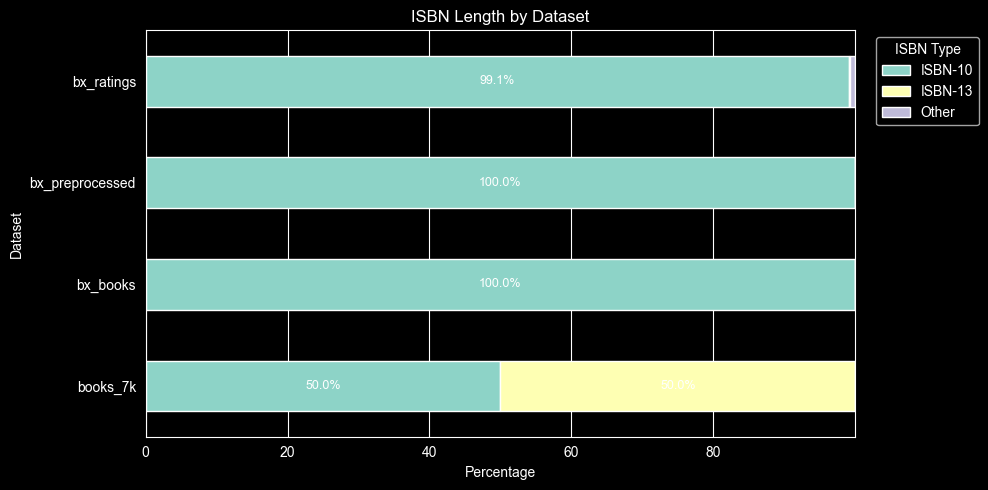

In [10]:
# ISBN length %
plot_df = isbn_summary_df.copy()

def isbn_category(length):
    if length == 10:
        return "ISBN-10"
    elif length == 13:
        return "ISBN-13"
    else:
        return "Other"

plot_df["isbn_category"] = plot_df["isbn_length"].apply(isbn_category)

summary_plot = (
    plot_df.groupby(["dataset", "isbn_category"])["count"]
    .sum()
    .reset_index()
)

pivot_df = summary_plot.pivot(
    index="dataset",
    columns="isbn_category",
    values="count"
).fillna(0)

pivot_df = pivot_df.reindex(columns=["ISBN-10", "ISBN-13", "Other"], fill_value=0)

percent_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

ax = percent_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 5)
)

ax.set_title("ISBN Length by Dataset")
ax.set_xlabel("Percentage")
ax.set_ylabel("Dataset")

for container in ax.containers:
    labels = []
    for bar in container:
        width = bar.get_width()
        labels.append(f"{width:.1f}%" if width > 3 else "")
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9)

plt.legend(title="ISBN Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

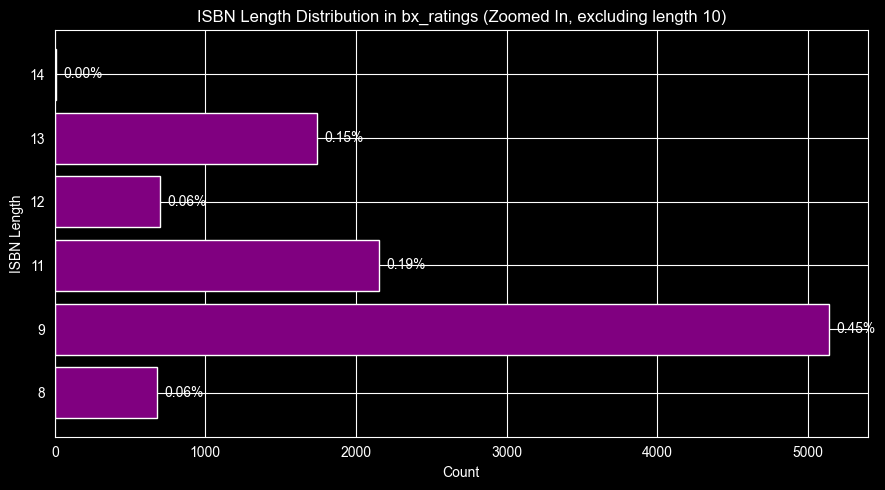

In [11]:
# zoom in on bx_isbn length for bx_ratings

# create summary table of ISBN lengths

bx_isbn = (

    bx_ratings["ISBN"]

    .astype(str)

    .str.len()

    .value_counts()

    .sort_index()

    .rename_axis("isbn_length")

    .reset_index(name="count"))

bx_isbn_zoom = bx_isbn[bx_isbn["isbn_length"] != 10].copy()

total = bx_isbn["count"].sum()

plt.figure(figsize=(9, 5))
bars = plt.barh(bx_isbn_zoom["isbn_length"].astype(str), bx_isbn_zoom["count"], color="purple")

plt.title("ISBN Length Distribution in bx_ratings (Zoomed In, excluding length 10)")
plt.xlabel("Count")
plt.ylabel("ISBN Length")

for bar, count in zip(bars, bx_isbn_zoom["count"]):
    pct = (count / total) * 100
    plt.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.2f}%",
        ha="left",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# Normalize Column Names Across Datasets

Taking books_7k as the standard, we first normalized the column names in order to later easliy identify potential merge keys.

In [12]:
# view columns books_7k
books_7k.head(1)



,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0


In [13]:

# check ISBN length in books_7k
print(books_7k["isbn13"].astype(str).str.len().value_counts().sort_index())
print(books_7k["isbn10"].astype(str).str.len().value_counts().sort_index())


isbn13
13    6810
Name: count, dtype: int64
isbn10
10    6810
Name: count, dtype: int64


In [14]:
# normalize column names where possible
books_7k = books_7k.rename(columns={
    "description" : "summary"
}).drop(columns=["isbn13", "subtitle", "thumbnail", "ratings_count"])

books_7k.head(1)


,isbn10,title,authors,categories,summary,published_year,average_rating,num_pages
0,0002005883,Gilead,Marilynne Robinson,Fiction,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0


In [15]:
# view columns bx_books
bx_books.head(1)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...


In [16]:
# check ISBN length in bx_books
print(bx_books["ISBN"].astype(str).str.len().value_counts().sort_index())

ISBN
10    271375
11         1
13         3
Name: count, dtype: int64


In [17]:
# drop ISBN length != 10
before = len(bx_books)
bx_books = bx_books[bx_books["ISBN"].astype(str).str.len() == 10].copy()
after = len(bx_books)

print(f"Before filter: {before:,}")
print(f"After filter : {after:,}")
print(f"Removed      : {before - after:,}")
print(f"\nISBN lengths remaining:")
print(bx_books["ISBN"].astype(str).str.len().value_counts().sort_index())

Before filter: 271,379
After filter : 271,375
Removed      : 4

ISBN lengths remaining:
ISBN
10    271375
Name: count, dtype: int64


In [18]:
# normalize column names where possible
bx_books = bx_books.rename(columns={
    "ISBN"                : "isbn10",
    "Book-Title"          : "title",
    "Book-Author"         : "authors",
    "Year-Of-Publication" : "published_year",
    "Publisher"           : "publisher"
}).drop(columns=["Image-URL-S", "Image-URL-M", "Image-URL-L"])

bx_books.head(1)

,isbn10,title,authors,published_year,publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press


In [19]:
# view columns bx_ratings
bx_ratings.head(1)


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0


In [20]:
# check ISBN length in bx_ratings
print(bx_ratings["ISBN"].astype(str).str.len().value_counts().sort_index())

ISBN
8         677
9        5140
10    1139363
11       2150
12        700
13       1740
14         10
Name: count, dtype: int64


In [21]:
# drop ISBN length != 10
before = len(bx_ratings)
bx_ratings = bx_ratings[bx_ratings["ISBN"].astype(str).str.len() == 10].copy()
after = len(bx_ratings)

print(f"Before filter: {before:,}")
print(f"After filter : {after:,}")
print(f"Removed      : {before - after:,}")
print(f"\nISBN lengths remaining:")
print(bx_ratings["ISBN"].astype(str).str.len().value_counts().sort_index())

Before filter: 1,149,780
After filter : 1,139,363
Removed      : 10,417

ISBN lengths remaining:
ISBN
10    1139363
Name: count, dtype: int64


In [22]:
# normalize column names where possible
bx_ratings = bx_ratings.rename(columns={
    "User-ID"       : "user_id",
    "ISBN"          : "isbn10",
    "Book-Rating"   : "rating",
})

bx_ratings.head(1)

,user_id,isbn10,rating
0,276725,034545104X,0


In [23]:
# # view columns bx_users
bx_users.head(1)


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN


In [24]:
# normalize column names where possible
bx_users = bx_users.rename(columns={
    "User-ID"     : "user_id",
    "Location"    : "location",
    "Age"         : "age",
})

bx_users.head(1)


,user_id,location,age
0,1,"nyc, new york, usa",NaN


In [25]:
# view columns bx_preprocessed
bx_preprocessed.head(1)


,Unnamed: 0,user_id,location,age,isbn,rating,book_title,book_author,year_of_publication,publisher,img_s,img_m,img_l,Summary,Language,Category,city,state,country
0,0,2,"stockton, california, usa",18.0,0195153448,0,Classical Mythology,Mark P. O. Morford,2002.0,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,Provides an introduction to classical myths pl...,en,['Social Science'],stockton,california,usa


In [26]:
# check ISBN length in bx_preprocessed
print(bx_preprocessed["isbn"].astype(str).str.len().value_counts().sort_index())


isbn
10    1031171
13          4
Name: count, dtype: int64


In [27]:
# drop ISBN length != 10
before = len(bx_preprocessed)
bx_preprocessed = bx_preprocessed[bx_preprocessed["isbn"].astype(str).str.len() == 10].copy()
after = len(bx_preprocessed)
print(f"Before filter: {before:,}")
print(f"After filter : {after:,}")
print(f"Removed      : {before - after:,}")
print(f"\nISBN lengths remaining:")
print(bx_preprocessed["isbn"].astype(str).str.len().value_counts().sort_index())



Before filter: 1,031,175
After filter : 1,031,171
Removed      : 4

ISBN lengths remaining:
isbn
10    1031171
Name: count, dtype: int64


In [28]:
# view bx_preprocessed columns
bx_preprocessed.columns.tolist()

['Unnamed: 0',
 'user_id',
 'location',
 'age',
 'isbn',
 'rating',
 'book_title',
 'book_author',
 'year_of_publication',
 'publisher',
 'img_s',
 'img_m',
 'img_l',
 'Summary',
 'Language',
 'Category',
 'city',
 'state',
 'country']

In [29]:
# normalize column names where possible
bx_preprocessed = bx_preprocessed.rename(columns={
    "isbn"                          : "isbn10",
    "book_title"                    : "title",
    "book_author"                   : "authors",
    "year_of_publication"           : "published_year",
    "Summary"                       : "summary",
    "Category"                      : "categories",
    "Language"                      : "language"
}).drop(columns=["Unnamed: 0", "img_s", "img_m","img_l","city","state","country"])

bx_preprocessed.head(1)


,user_id,location,age,isbn10,rating,title,authors,published_year,publisher,summary,language,categories
0,2,"stockton, california, usa",18.0,0195153448,0,Classical Mythology,Mark P. O. Morford,2002.0,Oxford University Press,Provides an introduction to classical myths pl...,en,['Social Science']


In [30]:
# view columns amazon_books_data
amazon_books_data.head(1)


,Title,description,authors,image,previewLink,publisher,publishedDate,infoLink,categories,ratingsCount
0,Its Only Art If Its Well Hung!,NaN,['Julie Strain'],http://books.google.com/books/content?id=DykPA...,http://books.google.nl/books?id=DykPAAAACAAJ&d...,NaN,1996,http://books.google.nl/books?id=DykPAAAACAAJ&d...,['Comics & Graphic Novels'],NaN


In [31]:
# normalize column names where possible
amazon_books_data = amazon_books_data.rename(columns={
    "Title"                : "title",
    "description"          : "summary",
    "publishedDate"        : "published_year",
}).drop(columns=["image", "previewLink", "infoLink", "ratingsCount"])

amazon_books_data.head(1)


,title,summary,authors,publisher,published_year,categories
0,Its Only Art If Its Well Hung!,NaN,['Julie Strain'],NaN,1996,['Comics & Graphic Novels']


In [32]:
## view columns amazon_books_ratings
amazon_books_ratings.head(1)

,Id,Title,Price,User_id,profileName,review/helpfulness,review/score,review/time,review/summary,review/text
0,1882931173,Its Only Art If Its Well Hung!,NaN,AVCGYZL8FQQTD,"Jim of Oz ""jim-of-oz""",7/7,4.0,940636800,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...


In [33]:
# check ISBN length in amazon_books_ratings
print(amazon_books_ratings["Id"].astype(str).str.len().value_counts().sort_index())



Id
10    3000000
Name: count, dtype: int64


In [34]:
# normalize column names where possible
amazon_books_ratings = amazon_books_ratings.rename(columns={
    "Id"                       : "isbn10",
    "Title"                    : "title",
    "User_id"                  : "user_id",
    "review/score"             : "rating",
    "review/summary"           : "summary",
    "review/text"              : "rating_explanation"
}).drop(columns=["Price", "profileName", "review/helpfulness","review/time"])

amazon_books_ratings.head(1)


,isbn10,title,user_id,rating,summary,rating_explanation
0,1882931173,Its Only Art If Its Well Hung!,AVCGYZL8FQQTD,4.0,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...


#Project Feasibility EDA

In [35]:
# check
print("books_7k:", books_7k.columns.tolist())
print("amazon_books_data:", amazon_books_data.columns.tolist())
print("amazon_books_ratings:", amazon_books_ratings.columns.tolist())
print("bx_users:", bx_users.columns.tolist())
print("bx_books:", bx_books.columns.tolist())
print("bx_ratings:", bx_ratings.columns.tolist())
print("bx_preprocessed:", bx_preprocessed.columns.tolist())

books_7k: ['isbn10', 'title', 'authors', 'categories', 'summary', 'published_year', 'average_rating', 'num_pages']
amazon_books_data: ['title', 'summary', 'authors', 'publisher', 'published_year', 'categories']
amazon_books_ratings: ['isbn10', 'title', 'user_id', 'rating', 'summary', 'rating_explanation']
bx_users: ['user_id', 'location', 'age']
bx_books: ['isbn10', 'title', 'authors', 'published_year', 'publisher']
bx_ratings: ['user_id', 'isbn10', 'rating']
bx_preprocessed: ['user_id', 'location', 'age', 'isbn10', 'rating', 'title', 'authors', 'published_year', 'publisher', 'summary', 'language', 'categories']


In [36]:
# check normalized and reduced  colnames map to see where each colname appears

col_map = {}

for name, df in [
    ("books_7k", books_7k),
    ("amazon_books_data", amazon_books_data),
    ("amazon_books_ratings", amazon_books_ratings),
    ("bx_users", bx_users),
    ("bx_books", bx_books),
    ("bx_ratings", bx_ratings),
    ("bx_preprocessed", bx_preprocessed),
]:
    for col in df.columns:
        col_map.setdefault(col, []).append(name)

col_map = dict(sorted(col_map.items()))

for col, datasets in col_map.items():
    print(f"{col}: {datasets}")

age: ['bx_users', 'bx_preprocessed']
authors: ['books_7k', 'amazon_books_data', 'bx_books', 'bx_preprocessed']
average_rating: ['books_7k']
categories: ['books_7k', 'amazon_books_data', 'bx_preprocessed']
isbn10: ['books_7k', 'amazon_books_ratings', 'bx_books', 'bx_ratings', 'bx_preprocessed']
language: ['bx_preprocessed']
location: ['bx_users', 'bx_preprocessed']
num_pages: ['books_7k']
published_year: ['books_7k', 'amazon_books_data', 'bx_books', 'bx_preprocessed']
publisher: ['amazon_books_data', 'bx_books', 'bx_preprocessed']
rating: ['amazon_books_ratings', 'bx_ratings', 'bx_preprocessed']
rating_explanation: ['amazon_books_ratings']
summary: ['books_7k', 'amazon_books_data', 'amazon_books_ratings', 'bx_preprocessed']
title: ['books_7k', 'amazon_books_data', 'amazon_books_ratings', 'bx_books', 'bx_preprocessed']
user_id: ['amazon_books_ratings', 'bx_users', 'bx_ratings', 'bx_preprocessed']


In [37]:
# create a dict for modified datasets
dataset_refs = {
    "books_7k": books_7k,
    "amazon_books_data": amazon_books_data,
    "amazon_books_ratings": amazon_books_ratings,
    "bx_users": bx_users,
    "bx_books": bx_books,
    "bx_ratings": bx_ratings,
    "bx_preprocessed": bx_preprocessed,
}

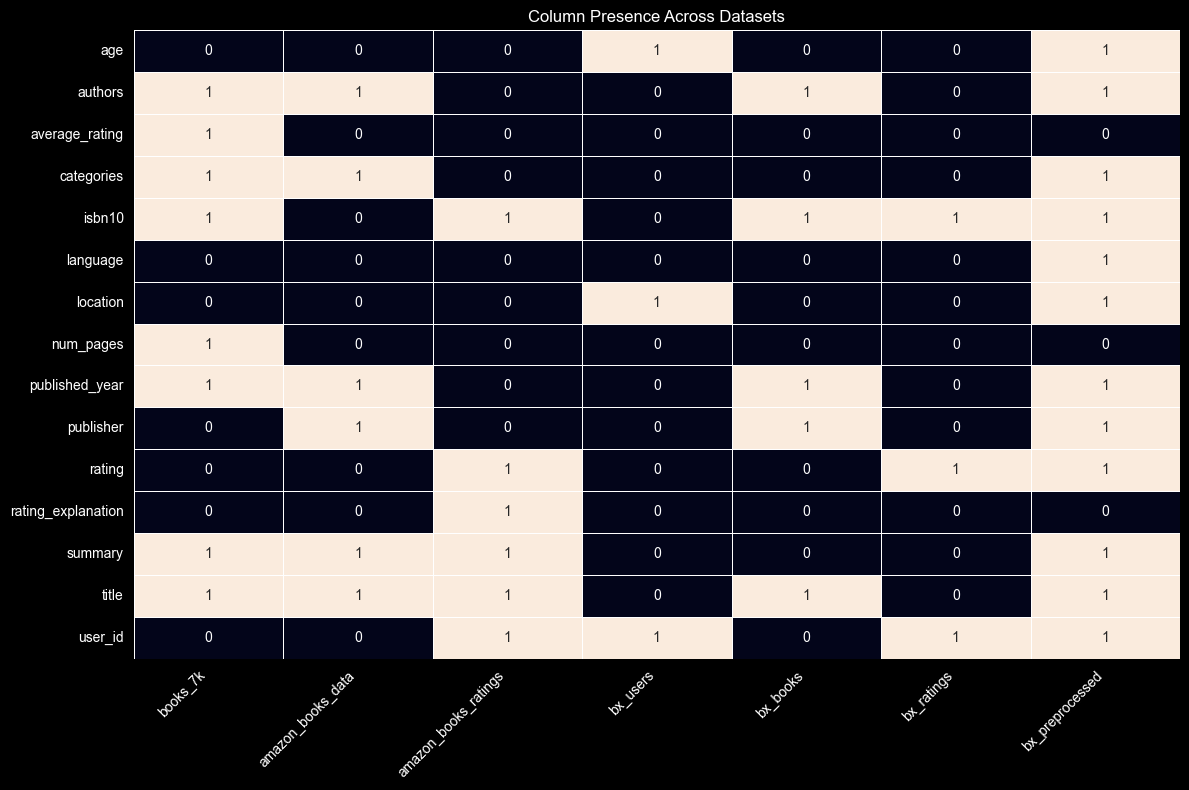

In [38]:
# create a merge key heatmap
dataset_refs = {
    "books_7k": books_7k,
    "amazon_books_data": amazon_books_data,
    "amazon_books_ratings": amazon_books_ratings,
    "bx_users": bx_users,
    "bx_books": bx_books,
    "bx_ratings": bx_ratings,
    "bx_preprocessed": bx_preprocessed,
}

all_cols = sorted(set(col for df in dataset_refs.values() for col in df.columns))

heatmap_df = pd.DataFrame(0, index=all_cols, columns=dataset_refs.keys())

for name, df in dataset_refs.items():
    for col in df.columns:
        heatmap_df.loc[col, name] = 1

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, annot=True, cbar=False, linewidths=0.5)
plt.title("Column Presence Across Datasets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Preprocessing

# Data Cleaning

## Data Cleaning Amazon Ratings Dataset

In [39]:
# Amazon ratings columns

print(amazon_books_ratings.columns)

Index(['isbn10', 'title', 'user_id', 'rating', 'summary',
       'rating_explanation'],
      dtype='str')


In [40]:
# missing values
print(f"\n == Missing Values == ")
print(amazon_books_ratings.isna().sum())


 == Missing Values == 
isbn10                     0
title                    208
user_id               561787
rating                     0
summary                  407
rating_explanation         8
dtype: int64


For collaborative filtering user_id, isbn10 and rating should not have NAs.

In [41]:
print("Before:", amazon_books_ratings.shape)

ratings = amazon_books_ratings.dropna(subset=["user_id"]).copy()

print("After:", ratings.shape)
print(ratings[["user_id"]].isna().sum())

Before: (3000000, 6)
After: (2438213, 6)
user_id    0
dtype: int64


In [42]:
# isbn10 check

isbn_len = ratings["isbn10"].astype(str).str.len()

print(isbn_len.value_counts().sort_index())

isbn10
10    2438213
Name: count, dtype: int64


In [43]:
# rating class balance

class_balance = pd.DataFrame({
    "count": ratings["rating"].value_counts().sort_index(),
    "percent": ratings["rating"].value_counts(normalize=True).sort_index().mul(100).round(2)
})

print("Unique rating values:")
print(sorted(ratings["rating"].unique()))
print("\nClass balance:")
print(class_balance)

Unique rating values:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

Class balance:
          count  percent
rating                  
1.0      151158     6.20
2.0      119634     4.91
3.0      212916     8.73
4.0      492174    20.19
5.0     1462331    59.98


There is a class imbalance.

In [44]:
# dedublicate
ratings.duplicated(subset=["user_id", "isbn10"]).sum()

np.int64(40599)

In [45]:
# before after dedublicaiton
print("Duplicate (user, book) pairs before:", ratings.duplicated(subset=["user_id", "isbn10"]).sum())

ratings = (
    ratings
    .sort_values("rating", ascending=False)
    .drop_duplicates(subset=["user_id", "isbn10"], keep="first")
    .reset_index(drop=True)
)

print("Duplicate (user, book) pairs after:", ratings.duplicated(subset=["user_id", "isbn10"]).sum())

Duplicate (user, book) pairs before: 40599
Duplicate (user, book) pairs after: 0


In [46]:
# unique users and books

print("Number of unique users:", ratings["user_id"].nunique())
print("Number of unique books:", ratings["isbn10"].nunique())



Number of unique users: 1008972
Number of unique books: 216023


In [47]:
# how sparse is the user-book rating matrix?
n_users = ratings["user_id"].nunique()
n_items = ratings["isbn10"].nunique()
n_observed = len(ratings)

sparsity = 1 - (n_observed / (n_users * n_items))

print("Matrix shape:", (n_users, n_items))
print("Observed ratings:", n_observed)
print("Sparsity:", round(sparsity * 100, 4), "%")

Matrix shape: (1008972, 216023)
Observed ratings: 2397614
Sparsity: 99.9989 %


In [48]:
#Filtering for users witgh >= 5 ratings and books with >= 10 ratings to improve sparsity.
min_user_ratings = 5
min_book_ratings = 10

user_counts = ratings["user_id"].value_counts()
book_counts = ratings["isbn10"].value_counts()   # or "isbn10" if that's your column

filtered_ratings = ratings[
    ratings["user_id"].isin(user_counts[user_counts >= min_user_ratings].index) &
    ratings["isbn10"].isin(book_counts[book_counts >= min_book_ratings].index)
].copy()

print("Original shape:", ratings.shape)
print("Filtered shape:", filtered_ratings.shape)
print("Unique users after filtering:", filtered_ratings["user_id"].nunique())
print("Unique books after filtering:", filtered_ratings["isbn10"].nunique())

Original shape: (2397614, 6)
Filtered shape: (962105, 6)
Unique users after filtering: 80527
Unique books after filtering: 36730


In [49]:
# check sparsity after filter
n_users = filtered_ratings["user_id"].nunique()
n_items = filtered_ratings["isbn10"].nunique()
n_observed = len(filtered_ratings)

sparsity = 1 - (n_observed / (n_users * n_items))

print("Filtered matrix shape:", (n_users, n_items))
print("Observed ratings:", n_observed)
print("Filtered sparsity:", round(sparsity * 100, 4), "%")

Filtered matrix shape: (80527, 36730)
Observed ratings: 962105
Filtered sparsity: 99.9675 %


Filtering for users witgh >= 5 ratings and books with >= 10 ratings did not improve sparsity.

In [50]:
# check distribution of ratings
user_counts = ratings["user_id"].value_counts()
book_counts = ratings["isbn10"].value_counts()

print("Users with 1 rating:", (user_counts == 1).sum())
print("Users with 2–5 ratings:", ((user_counts >= 2) & (user_counts <= 5)).sum())
print("Users with > 5 ratings:", (user_counts > 5).sum())
print("Books with 1 rating:", (book_counts == 1).sum())
print("Books with 2–5 ratings:", ((book_counts >= 2) & (book_counts <= 5)).sum())
print("Books with > 5 ratings:", (book_counts > 5).sum())

Users with 1 rating: 700296
Users with 2–5 ratings: 244213
Users with > 5 ratings: 64463
Books with 1 rating: 75727
Books with 2–5 ratings: 79551
Books with > 5 ratings: 60745


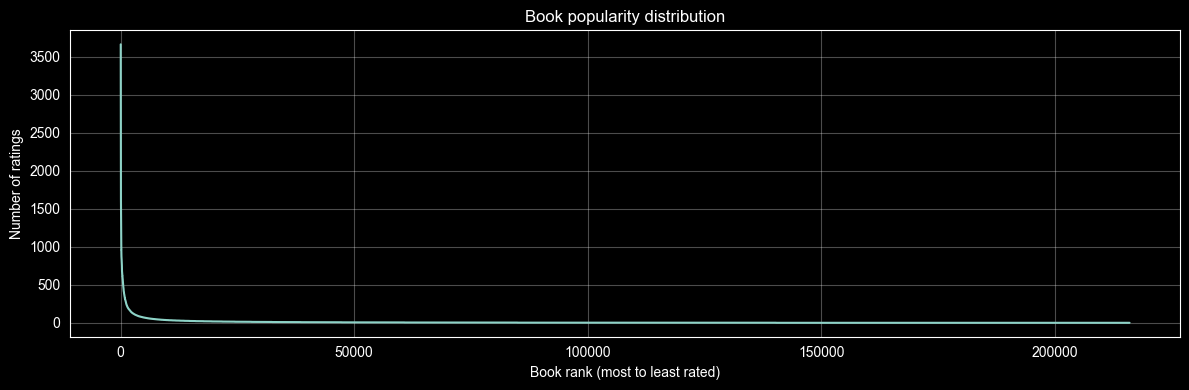

In [51]:
# check distribution
book_counts = ratings["isbn10"].value_counts().reset_index()
book_counts.columns = ["isbn10", "rating_count"]

plt.figure(figsize=(12, 4))
plt.plot(np.arange(1, len(book_counts) + 1), book_counts["rating_count"])
plt.title("Book popularity distribution")
plt.xlabel("Book rank (most to least rated)")
plt.ylabel("Number of ratings")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Collaborative filtering i.e. " a type of recommendation algorithm that suggests items to users based on the preferences and behaviour of similar users (co-occurance)" [Source](https://jerichosiahaya.medium.com/item-based-collaborative-filtering-explained-eaf3e31f39c1)



In [52]:
# check if enough unique isnb10 values match for a join
ratings_isbns_check = set(ratings["isbn10"].dropna().astype(str).str.strip())
books7k_isbns_check = set(books_7k["isbn10"].dropna().astype(str).str.strip())

matched = ratings_isbns_check & books7k_isbns_check

print("Unique isbn10 in amazon_books_ratings:", len(ratings_isbns_check))
print("Unique isbn10 in books_7k:", len(books7k_isbns_check))
print("Matched unique isbn10:", len(matched))
print("Match rate:", len(matched) / len(ratings_isbns_check) * 100)


Unique isbn10 in amazon_books_ratings: 216023
Unique isbn10 in books_7k: 6810
Matched unique isbn10: 457
Match rate: 0.21155154775185978


In [53]:
# save output
ratings.to_csv(BASE_DIR / "clean" / "amazon_books_ratings_clean.csv", index=False)

## Prep Amazon Book Ratings Dataset for Collaborative Filtering (potentially on MYSQL)

In [54]:
# minimum activity thresholds
min_user_ratings= 2   # must have rated at least 2 books to create any co-occurrence
min_book_ratings = 10  # enough signal for matrix; decision rule filters to 30 at query time

user_counts = ratings["user_id"].value_counts()
book_counts = ratings["isbn10"].value_counts()

ratings_cf = ratings[
    ratings["user_id"].isin(user_counts[user_counts >= min_user_ratings].index) &
    ratings["isbn10"].isin(book_counts[book_counts >= min_book_ratings].index)
].copy()

print("Original shape:", ratings.shape)
print("CF-ready shape:", ratings_cf.shape)
print("Unique users:  ", ratings_cf["user_id"].nunique())
print("Unique books:  ", ratings_cf["isbn10"].nunique())

Original shape: (2397614, 6)
CF-ready shape: (1426192, 6)
Unique users:   283717
Unique books:   38293


In [55]:
# check if same user has rated the same book more than once
dupes = ratings_cf.duplicated(subset=["user_id", "isbn10"]).sum()
print("Duplicate (user, book) pairs:", dupes)

Duplicate (user, book) pairs: 0


In [56]:
# deduplication
before_dedup = len(ratings_cf)

ratings_cf = (
    ratings_cf
    .sort_values("rating", ascending=False)
    .drop_duplicates(subset=["user_id", "isbn10"], keep="first")
    .reset_index(drop=True)
)

print("Before dedup:", before_dedup)
print("After dedup: ", len(ratings_cf))
print("Removed:     ", before_dedup - len(ratings_cf))

Before dedup: 1426192
After dedup:  1426192
Removed:      0


In [57]:
# check rating values
print(ratings_cf["rating"].unique())
print(ratings_cf["rating"].isna().sum())

[5. 4. 3. 2. 1.]
0


In [58]:
# filter to user liked both books (co-occurance) >= 4

ratings_cf = ratings_cf[ratings_cf["rating"] >= 4].copy()
print("After liked filter:", ratings_cf.shape)

After liked filter: (1137801, 6)


In [59]:
# check shape after filtering

user_counts = ratings_cf["user_id"].value_counts()
book_counts = ratings_cf["isbn10"].value_counts()

ratings_cf = ratings_cf[
    ratings_cf["user_id"].isin(user_counts[user_counts >= 2].index) &
    ratings_cf["isbn10"].isin(book_counts[book_counts >= 10].index)
].copy()

print("Final shape:  ", ratings_cf.shape)
print("Unique users: ", ratings_cf["user_id"].nunique())
print("Unique books: ", ratings_cf["isbn10"].nunique())

Final shape:   (1010877, 6)
Unique users:  195974
Unique books:  19572


In [60]:
# check balance
print(ratings_cf["rating"].value_counts().sort_index())

rating
4.0    269095
5.0    741782
Name: count, dtype: int64


In [61]:
# summary overview of amazon ratings dataset ready for cf matrix building
print("=== CF-Ready Dataset Summary ===")
print(f"Total liked interactions : {len(ratings_cf):,}")
print(f"Unique users             : {ratings_cf['user_id'].nunique():,}")
print(f"Unique books             : {ratings_cf['isbn10'].nunique():,}")
print(f"Nulls                    : {ratings_cf.isna().sum().sum()}")
print(f"Duplicates               : {ratings_cf.duplicated(subset=['user_id', 'isbn10']).sum()}")
print(f"Low ratings (< 4)        : {(ratings_cf['rating'] < 4).sum()}") # for co-occurance matrix
print(f"Dtypes OK                : {list(ratings_cf.dtypes.astype(str).values)}")

=== CF-Ready Dataset Summary ===
Total liked interactions : 1,010,877
Unique users             : 195,974
Unique books             : 19,572
Nulls                    : 371
Duplicates               : 0
Low ratings (< 4)        : 0
Dtypes OK                : ['str', 'str', 'str', 'float64', 'str', 'str']


## Data cleaning second dataset (books_7k)

In [62]:
ratings_isbns = set(ratings_cf["isbn10"].dropna().astype(str).str.strip())
books7k_isbns = set(books_7k["isbn10"].dropna().astype(str).str.strip())

matched = ratings_isbns & books7k_isbns

print("Unique isbn10 in ratings_cf:", len(ratings_isbns))
print("Unique isbn10 in books_7k:", len(books7k_isbns))
print("Matched unique isbn10:", len(matched))
print("Match rate:", len(matched) / len(ratings_isbns) * 100)

Unique isbn10 in ratings_cf: 19572
Unique isbn10 in books_7k: 6810
Matched unique isbn10: 177
Match rate: 0.9043531575720416


In [64]:
datasets = {
    "books_7k": books_7k,
    "amazon_books_data": amazon_books_data,
    "amazon_books_ratings": amazon_books_ratings,
    "bx_users": bx_users,
    "bx_books": bx_books,
    "bx_ratings": bx_ratings,
    "bx_preprocessed": bx_preprocessed,
}

In [65]:
# choosing which datasets to join ratings_cf by matching isbn10
cf_isbns = set(ratings_cf["isbn10"].unique())
print(f"ratings_cf unique isbn10s: {len(cf_isbns):,}\n")

for name, df in datasets.items():
    for col in df.columns:
        if any(k in col.lower() for k in ["isbn", "id", "title"]):
            # normalise and filter to length 10 only
            cleaned = (
                df[col]
                .astype(str)
                .str.replace("-", "", regex=False)
                .str.strip()
            )
            valid_10 = set(cleaned[cleaned.str.len() == 10].unique())
            overlap  = cf_isbns & valid_10

            if len(overlap) > 0:
                print(f"{name}['{col}']")
                print(f"  valid isbn10s in column : {len(valid_10):,}")
                print(f"  overlapping with cf     : {len(overlap):,}")

ratings_cf unique isbn10s: 19,572

books_7k['isbn10']
  valid isbn10s in column : 6,810
  overlapping with cf     : 177
amazon_books_ratings['isbn10']
  valid isbn10s in column : 221,998
  overlapping with cf     : 19,572
bx_books['isbn10']
  valid isbn10s in column : 271,375
  overlapping with cf     : 2,315
bx_ratings['isbn10']
  valid isbn10s in column : 332,287
  overlapping with cf     : 2,360
bx_preprocessed['isbn10']
  valid isbn10s in column : 270,167
  overlapping with cf     : 2,305
